In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [8]:
import pandas as pd

df = pd.read_parquet("/Users/bsama/Desktop/emotion recognition/0000.parquet")

print(df.columns)
print(df.head())
print(df.shape)

Index(['img_bytes', 'labels'], dtype='object')
                                           img_bytes  labels
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
(35887, 2)


In [10]:
LABEL_COL = "labels"

unlabelled = df[df[LABEL_COL].isna() | (df[LABEL_COL] == "")]
print("Unlabelled images:", len(unlabelled))
unlabelled.head()

Unlabelled images: 0


,img_bytes,labels


In [37]:
df["labels"].value_counts().sort_index()

labels
0    4953
1     547
2    5121
3    8989
4    6198
5    6077
6    4002
Name: count, dtype: int64

In [12]:
counts = df[LABEL_COL].value_counts()
print("Imbalance ratio:", counts.max()/counts.min())

Imbalance ratio: 16.43327239488117


In [26]:
type(df["img_bytes"][0])

bytes

In [27]:
from PIL import Image
import io

corrupt = 0

for img in df["img_bytes"].head(35887):  # check all sample
    try:
        Image.open(io.BytesIO(img)).verify()  # verify image integrity
    except:
        corrupt += 1

print("Corrupt images found:", corrupt)

Corrupt images found: 0


In [28]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 1793


In [35]:
df["labels"].isna().sum()

np.int64(0)

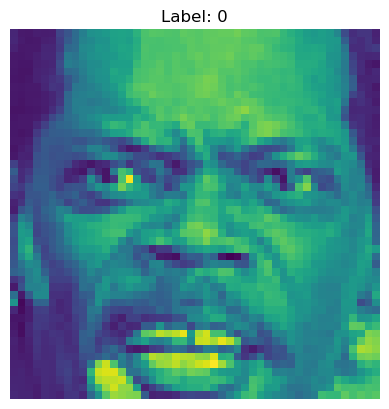

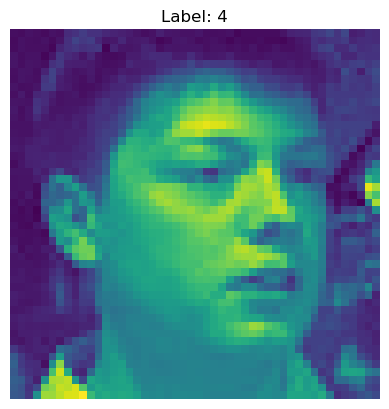

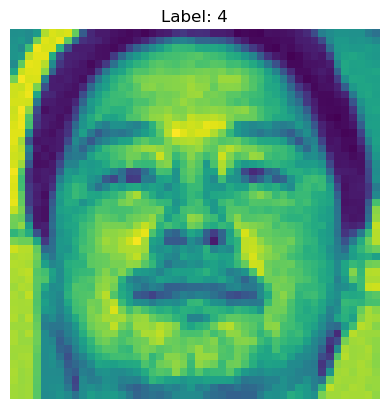

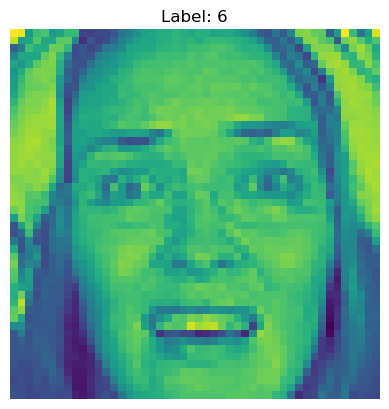

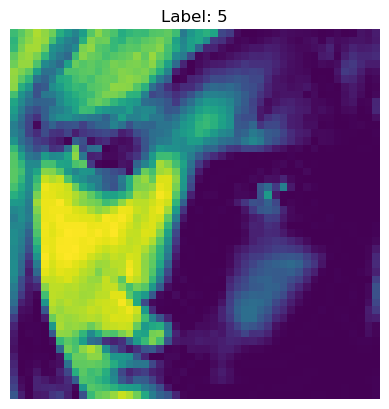

In [38]:
import matplotlib.pyplot as plt
import random
import io
from PIL import Image

for i in random.sample(range(len(df)), 5):
    img = Image.open(io.BytesIO(df["img_bytes"][i]))
    label = df["labels"][i]

    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()